In [1]:
import pandas as pd
import numpy as np
import shap
import seaborn as sns
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, train_test_split, GroupKFold
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor
import matplotlib.pyplot as plt

In [2]:
input_file = '55Mn.xlsx'
df = pd.read_excel(input_file) 

In [3]:
df_solvent=df.drop(columns=['SMILES','T','Chem_shift','References', 'Solvent_name','Solvent_SMILES'], axis=1)
df_solvent

,"Density, g/mL","Molar volume, mL/mol",Refractive index,"Molecular refractive power, mL/mol",Dielectric constant,"Dipole moment, D","Melting point, °C",Boiling point. °C,Vapour pressure. Torr,"Surface tension, dyn/cm",...,Hildebrant solubility parameter (δ),Snyder P',"Hansen solubility parameter δd, (cal/mL)½","Hansen solubility parameter δp, (cal/mL)½","Hansen solubility parameter δh, (cal/mL)½",Kauri butanol value,"Solvent strength (ε0, silica)","Solvent strength (ε0, alumina)","Specific heat capacity, cal/molK",Latent heat of fusion. cal/mol
0,1.489,80.2,1.446,21.37,4.81,1.15,-64,61.0,158,27.16,...,9.3,4.1,8.7,1.5,2.8,NaN,0.26,0.40,27,2097.0
1,0.879,88.9,1.501,26.20,2.28,0.00,6,81.0,78,28.90,...,9.2,2.7,9.0,0.0,1.0,112.0,0.25,0.32,31,2375.0
2,0.879,88.9,1.501,26.20,2.28,0.00,6,81.0,78,28.90,...,9.2,2.7,9.0,0.0,1.0,112.0,0.25,0.32,31,2375.0
3,0.879,88.9,1.501,26.20,2.28,0.00,6,81.0,78,28.90,...,9.2,2.7,9.0,0.0,1.0,112.0,0.25,0.32,31,2375.0
4,1.489,80.2,1.446,21.37,4.81,1.15,-64,61.0,158,27.16,...,9.3,4.1,8.7,1.5,2.8,NaN,0.26,0.40,27,2097.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,1.326,64.1,1.424,16.35,8.93,1.14,-95,39.0,350,28.12,...,9.7,3.1,8.9,3.1,3.0,136.0,0.32,0.42,24,1436.0
425,1.326,64.1,1.424,16.35,8.93,1.14,-95,39.0,350,28.12,...,9.7,3.1,8.9,3.1,3.0,136.0,0.32,0.42,24,1436.0
426,1.326,64.1,1.424,16.35,8.93,1.14,-95,39.0,350,28.12,...,9.7,3.1,8.9,3.1,3.0,136.0,0.32,0.42,24,1436.0
427,0.887,81.3,1.407,20.02,7.58,1.69,-108,65.0,142,26.40,...,9.1,4.0,8.2,2.8,3.9,NaN,0.35,0.45,36,NaN


In [4]:
def RDkit_descriptors(smiles, suffix=""):
    mols = [Chem.MolFromSmiles(i) for i in smiles] 
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_names = calc.GetDescriptorNames()
    if suffix:
        desc_names = [name + suffix for name in desc_names]
    Mol_descriptors = []
    for mol in mols:
        descriptors = calc.CalcDescriptors(mol)
        Mol_descriptors.append(descriptors)
    return Mol_descriptors, desc_names    

In [5]:
Mol_descriptors_HBA,desc_names = RDkit_descriptors(df['SMILES'])
df_target = pd.DataFrame(Mol_descriptors_HBA,columns=desc_names)
df_target

[10:08:01] Conflicting single bond directions around double bond at index 6.
[10:08:01]   BondStereo set to STEREONONE and single bond directions set to NONE.


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.388835,12.388835,0.567118,-5.426065,0.624673,24.208333,465.272,451.160,463.894819,126,...,0,0,0,0,0,0,0,0,0,0
1,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,0
2,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,0
3,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,0
4,12.303765,12.303765,0.482049,-5.766343,0.688186,24.208333,420.821,406.709,419.945334,126,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,13.706246,13.706246,0.232297,-5.833333,0.237798,26.911765,568.985,524.633,568.183466,194,...,0,0,0,0,0,0,0,0,0,0
425,11.289892,11.289892,0.221204,-4.876227,0.510641,29.562500,358.934,352.886,357.835600,84,...,0,0,0,0,0,0,0,0,0,0
426,11.204822,11.204822,0.372438,-5.216505,0.523619,29.562500,314.483,308.435,313.886115,84,...,0,0,0,0,0,0,0,0,0,0
427,12.258233,12.258233,0.257685,-6.242326,0.414362,23.440000,428.309,418.229,427.913309,125,...,0,0,0,0,0,0,0,0,0,0


In [6]:
Mol_descriptors, desc_names_sol = RDkit_descriptors(df['Solvent_SMILES'], suffix="_sol")
df_solvent_RDKit = pd.DataFrame(Mol_descriptors, columns=desc_names_sol)
df_solvent_RDKit

,MaxAbsEStateIndex_sol,MaxEStateIndex_sol,MinAbsEStateIndex_sol,MinEStateIndex_sol,qed_sol,SPS_sol,MolWt_sol,HeavyAtomMolWt_sol,ExactMolWt_sol,NumValenceElectrons_sol,...,fr_sulfide_sol,fr_sulfonamd_sol,fr_sulfone_sol,fr_term_acetylene_sol,fr_tetrazole_sol,fr_thiazole_sol,fr_thiocyan_sol,fr_thiophene_sol,fr_unbrch_alkane_sol,fr_urea_sol
0,4.805556,4.805556,0.750000,-0.750000,0.427859,9.0,119.378,118.370,117.914383,26,...,0,0,0,0,0,0,0,0,0,0
1,2.000000,2.000000,2.000000,2.000000,0.442628,8.0,78.114,72.066,78.046950,30,...,0,0,0,0,0,0,0,0,0,0
2,2.000000,2.000000,2.000000,2.000000,0.442628,8.0,78.114,72.066,78.046950,30,...,0,0,0,0,0,0,0,0,0,0
3,2.000000,2.000000,2.000000,2.000000,0.442628,8.0,78.114,72.066,78.046950,30,...,0,0,0,0,0,0,0,0,0,0
4,4.805556,4.805556,0.750000,-0.750000,0.427859,9.0,119.378,118.370,117.914383,26,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,4.763889,4.763889,0.194444,0.194444,0.389962,6.0,84.933,82.917,83.953355,20,...,0,0,0,0,0,0,0,0,0,0
425,4.763889,4.763889,0.194444,0.194444,0.389962,6.0,84.933,82.917,83.953355,20,...,0,0,0,0,0,0,0,0,0,0
426,4.763889,4.763889,0.194444,0.194444,0.389962,6.0,84.933,82.917,83.953355,20,...,0,0,0,0,0,0,0,0,0,0
427,4.944444,4.944444,1.000000,1.000000,0.410938,24.0,72.107,64.043,72.057515,30,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_all = pd.concat([df_target, df_solvent, df_solvent_RDKit, df['T']], axis=1)
df_all

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfonamd_sol,fr_sulfone_sol,fr_term_acetylene_sol,fr_tetrazole_sol,fr_thiazole_sol,fr_thiocyan_sol,fr_thiophene_sol,fr_unbrch_alkane_sol,fr_urea_sol,T
0,12.388835,12.388835,0.567118,-5.426065,0.624673,24.208333,465.272,451.160,463.894819,126,...,0,0,0,0,0,0,0,0,0,300
1,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,300
2,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,300
3,11.822040,11.822040,0.153188,-7.216154,0.448212,29.769231,414.245,395.093,414.035867,146,...,0,0,0,0,0,0,0,0,0,300
4,12.303765,12.303765,0.482049,-5.766343,0.688186,24.208333,420.821,406.709,419.945334,126,...,0,0,0,0,0,0,0,0,0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,13.706246,13.706246,0.232297,-5.833333,0.237798,26.911765,568.985,524.633,568.183466,194,...,0,0,0,0,0,0,0,0,0,300
425,11.289892,11.289892,0.221204,-4.876227,0.510641,29.562500,358.934,352.886,357.835600,84,...,0,0,0,0,0,0,0,0,0,300
426,11.204822,11.204822,0.372438,-5.216505,0.523619,29.562500,314.483,308.435,313.886115,84,...,0,0,0,0,0,0,0,0,0,300
427,12.258233,12.258233,0.257685,-6.242326,0.414362,23.440000,428.309,418.229,427.913309,125,...,0,0,0,0,0,0,0,0,0,302


In [8]:
X = df_all.select_dtypes(include=[np.number]).copy()
y = df['Chem_shift']
X = X.loc[y.index]
X.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
variance_eps = 1e-6
vt = VarianceThreshold(threshold=variance_eps)

X_var = pd.DataFrame(
    vt.fit_transform(X),
    columns=X.columns[vt.get_support()],
    index=X.index
)

cb_base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cb_base.fit(X_var, y)

gini_importance = pd.Series(
    cb_base.get_feature_importance(type="FeatureImportance"),
    index=X_var.columns,
    name="gini"
)

explainer = shap.TreeExplainer(cb_base)
shap_values = explainer.shap_values(X_var)

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_var.columns,
    name="shap"
)

def safe_pearson(col, y):
    mask = col.notna() & y.notna()
    if mask.sum() < 3:
        return 0.0
    if col[mask].std() < 1e-12:
        return 0.0
    return np.corrcoef(col[mask], y[mask])[0, 1]

pearson_corr = X_var.apply(lambda col: abs(safe_pearson(col, y)))
pearson_corr.name = "pearson"

imp_df = pd.concat(
    [gini_importance, shap_importance, pearson_corr],
    axis=1
).fillna(0.0)

scaler = MinMaxScaler()

imp_norm = pd.DataFrame(
    scaler.fit_transform(imp_df),
    columns=imp_df.columns,
    index=imp_df.index
)

imp_norm["composite"] = (
    0.4 * imp_norm["gini"] +
    0.4 * imp_norm["shap"] +
    0.2 * imp_norm["pearson"]
)

imp_norm = imp_norm.sort_values("composite", ascending=False)

corr_threshold = 0.98
selected_features = []

corr_matrix = X_var[imp_norm.index].corr().abs()

for feat in imp_norm.index:
    keep = True
    for sel in selected_features:
        if corr_matrix.loc[feat, sel] > corr_threshold:
            keep = False
            break
    if keep:
        selected_features.append(feat)

print(f"Total number of numerical features: {X.shape[1]}")
print(f"After VarianceThreshold: {X_var.shape[1]}")
print(f"After correlation selection: {len(selected_features)}")

selected_features[:20]

/home/iyar/anaconda3/envs/py_311/lib/python3.11/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


Total number of numerical features: 464
After VarianceThreshold: 302
After correlation selection: 227


['VSA_EState2',
 'SMR_VSA1',
 'SPS',
 'NumAliphaticHeterocycles',
 'TPSA',
 'fr_halogen',
 'fr_C_O_noCOO',
 'VSA_EState3',
 'NumHeterocycles',
 'MinEStateIndex',
 'NumHAcceptors',
 'VSA_EState10',
 'fr_allylic_oxid',
 'VSA_EState9',
 'FpDensityMorgan3',
 'NOCount',
 'VSA_EState7',
 'SlogP_VSA3',
 'NumAliphaticRings',
 'FpDensityMorgan2']

In [10]:
def evaluate_single_model(n_features, X_var, y, selected_features, n_splits=5, 
                          save_plot=True, plot_filename='predictions_plot.jpeg'):

    if n_features > len(selected_features):
        print(f"Attention: {n_features} features were requested, but only {len(selected_features)}")
        n_features = len(selected_features)
    
    feats = selected_features[:n_features]
    print(f"Using {len(feats)} features from {len(selected_features)} available")
    
    r2_scores, rmse_scores, mae_scores = [], [], []
    
    all_y_true = []
    all_y_pred = []
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_var), 1):
        X_train = X_var.iloc[train_idx][feats]
        X_val = X_var.iloc[val_idx][feats]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        model = TabPFNRegressor()
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        
        all_y_true.extend(y_val.values)
        all_y_pred.extend(y_pred)
        
        r2 = r2_score(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = mean_absolute_error(y_val, y_pred)
        
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        
        print(f"  Fold {fold}: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")
    
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    
    final_r2 = np.mean(r2_scores)
    final_r2_std = np.std(r2_scores)
    final_rmse = np.mean(rmse_scores)
    final_rmse_std = np.std(rmse_scores)
    final_mae = np.mean(mae_scores)
    final_mae_std = np.std(mae_scores)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(
        all_y_true, all_y_pred,
        color='brown',
        edgecolor='black',
        linewidth=0.5,
        alpha=0.7,
        s=50,
        label='Predictions'
    )
    
    min_val = min(all_y_true.min(), all_y_pred.min())
    max_val = max(all_y_true.max(), all_y_pred.max())
    ideal_line = ax.plot([min_val, max_val], [min_val, max_val], "k--", lw=4, label='Ideal prediction')
    
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Experimental, ppm", fontsize=14)
    ax.set_ylabel("Predicted, ppm", fontsize=14)
    ax.set_xlim([min_val - 0.1*(max_val-min_val), max_val + 0.1*(max_val-min_val)])
    ax.set_ylim([min_val - 0.1*(max_val-min_val), max_val + 0.1*(max_val-min_val)])
    
    if save_plot:
        plt.savefig(plot_filename, format='jpeg', dpi=300, bbox_inches='tight')
        print(f"\nGraph save as '{plot_filename}'")
    
    plt.show()

    results = {
        'n_features': n_features,
        'R2': f"{final_r2:.4f} ± {final_r2_std:.4f}",
        'RMSE': f"{final_rmse:.4f} ± {final_rmse_std:.4f}",
        'MAE': f"{final_mae:.4f} ± {final_mae_std:.4f}",
        'R2_raw': (final_r2, final_r2_std),
        'RMSE_raw': (final_rmse, final_rmse_std),
        'MAE_raw': (final_mae, final_mae_std),
        'r2_scores': r2_scores,
        'rmse_scores': rmse_scores,
        'mae_scores': mae_scores,
        'all_y_true': all_y_true,
        'all_y_pred': all_y_pred
    }
    
    print(f"\n{'='*60}")
    print(f"Final results for {n_features} features:")
    print('='*60)
    print(f"R²:   {results['R2']}")
    print(f"RMSE: {results['RMSE']}")
    print(f"MAE:  {results['MAE']}")
    print('='*60)
    
    return results, fig, ax

Using 210 features from 227 available
  Fold 1: R²=0.8812, RMSE=297.4949, MAE=160.0922
  Fold 2: R²=0.9406, RMSE=192.2898, MAE=110.8458
  Fold 3: R²=0.7596, RMSE=382.5726, MAE=178.1272
  Fold 4: R²=0.8365, RMSE=328.2470, MAE=152.9079
  Fold 5: R²=0.8163, RMSE=348.7189, MAE=162.6106

Graph save as 'tabpfn_Mo.jpeg'


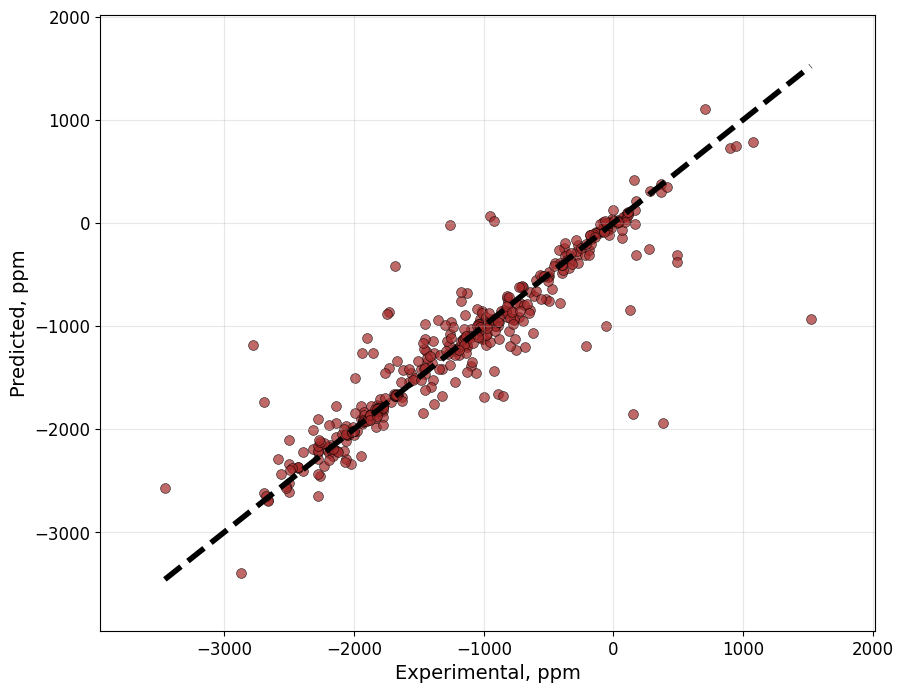


Final results for 210 features:
R²:   0.8468 ± 0.0610
RMSE: 309.8646 ± 64.9783
MAE:  152.9167 ± 22.5875


In [11]:
desired_n_features = 210 
results, fig, ax = evaluate_single_model(
    n_features=desired_n_features,
    X_var=X_var,
    y=y,
    selected_features=selected_features,
    n_splits=5,
    save_plot=True,
    plot_filename=f'tabpfn_Mo.jpeg'
)